In [7]:
#Import and Install Libraries
import pandas as pd 
import numpy as np 
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

#Show data Uploaded Successfully
print("Data Uploaded Successfully")




Data Uploaded Successfully


In [8]:
#Data Collection
print("Section 2: Data Collection")
print("-"*50)

transactions_df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)

print(f"Data Shape: {transactions_df.shape}")
print(f"Total Transactions: {len(transactions_df)}")
print("\nFirst 10 rows of raw data:")
print(transactions_df.head(10).to_string(index=False))


Section 2: Data Collection
--------------------------------------------------
Data Shape: (7501, 20)
Total Transactions: 7501

First 10 rows of raw data:
               0            1          2                3            4                5    6              7            8            9              10        11    12    13            14     15                16              17      18        19
           shrimp      almonds    avocado   vegetables mix green grapes whole weat flour yams cottage cheese energy drink tomato juice low fat yogurt green tea honey salad mineral water salmon antioxydant juice frozen smoothie spinach olive oil
          burgers    meatballs       eggs              NaN          NaN              NaN  NaN            NaN          NaN          NaN            NaN       NaN   NaN   NaN           NaN    NaN               NaN             NaN     NaN       NaN
          chutney          NaN        NaN              NaN          NaN              NaN  NaN            NaN   

In [9]:
#Data Preprocessing
print("Section 2b: Data Preprocessing")
print("-"*50)

#Step 1: Standardize the data 
transactions_df = transactions_df.map(
    lambda x: str(x).strip() if pd.notnull(x) else x
)

#Step 2: Build transaction list (Remove NaN values)
Transaction_list = []
for i in range(len(transactions_df)):
    transaction = [item for item in transactions_df.iloc[i].tolist()
                   if item != 'nan']
    if len(transaction) > 0:
        Transaction_list.append(transaction)

print(f"Total Transactions prepared: {len(Transaction_list)}")
print("\nFirst 5 transactions:")
for i, t in enumerate (Transaction_list[:5]):
    print(f"Transaction {i+1}: {t}")

#Step 3: Remove duplicates within each transaction
transaction_list = [list(dict.fromkeys(t)) for t in Transaction_list]
print(f"Total Transactions after removing duplicates: {len(transaction_list)}")





    

Section 2b: Data Preprocessing
--------------------------------------------------
Total Transactions prepared: 7501

First 5 transactions:
Transaction 1: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
Transaction 2: ['burgers', 'meatballs', 'eggs', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
Transaction 3: ['chutney', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
Transaction 4: ['turkey', 'avocado', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
Transaction 5: ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
Total Transactio

In [10]:
#Step 4: Encode transactions using TransactionEncoder
import pandas as pd 

#Clean drop NaN and force every item to be a string
transaction_list = [
    [str(item).strip() for item in transaction if pd.notnull(item)]
    for transaction in Transaction_list
]

te = TransactionEncoder()
te_array = te.fit(transaction_list).transform(transaction_list)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"encoded Data Shape: {df_encoded.shape}")
print("\nFirst 5 rows (First 10 columns):")
print(df_encoded.iloc[:5, :10])

encoded Data Shape: (7501, 119)

First 5 rows (First 10 columns):
   almonds  antioxydant juice  asparagus  avocado  babies food  bacon  \
0     True               True      False     True        False  False   
1    False              False      False    False        False  False   
2    False              False      False    False        False  False   
3    False              False      False     True        False  False   
4    False              False      False    False        False  False   

   barbecue sauce  black tea  blueberries  body spray  
0           False      False        False       False  
1           False      False        False       False  
2           False      False        False       False  
3           False      False        False       False  
4           False      False        False       False  


In [11]:
#Section 3: Threshold Selection 
print("Section 3: Threshold Selection")
print("-"*65)

experiments = [
    {"set": 1, "min_support": 0.010, "min_confidence": 0.20, "min_lift": 3},
    {"set": 2, "min_support": 0.005, "min_confidence": 0.30, "min_lift": 3},
    {"set": 3, "min_support": 0.003, "min_confidence": 0.40, "min_lift": 3},
    {"set": 4, "min_support": 0.002, "min_confidence": 0.20, "min_lift": 2}
]

print(f"{'Set':<5} {'Min Support':<12} {'Min Confidence':<15} {'Min Lift':<10}")

for exp in experiments:
    print(f"{exp['set']:<5} {exp['min_support']:<12.3f} {exp['min_confidence']:<15.2f} {exp['min_lift']:<10.2f}")
    print("-"*65)

for exp in experiments: 
    fi = apriori(df_encoded, min_support=exp['min_support'], use_colnames=True)
    if fi.empty:
        count=0

    else:
        r = association_rules(fi, metric="confidence", min_threshold=exp['min_confidence'])
        r = r[r['lift'] >= exp['min_lift']]
        count = len(r)
    print(f"{exp['set']:<6} {exp['min_support']:<15} {exp['min_confidence']:18} {exp['min_lift']:<12} {count} Rules")

    print("Selected: Set 3 (balanced, not too many or too few rules)")

Section 3: Threshold Selection
-----------------------------------------------------------------
Set   Min Support  Min Confidence  Min Lift  
1     0.010        0.20            3.00      
-----------------------------------------------------------------
2     0.005        0.30            3.00      
-----------------------------------------------------------------
3     0.003        0.40            3.00      
-----------------------------------------------------------------
4     0.002        0.20            2.00      
-----------------------------------------------------------------
1      0.01                           0.2 3            1 Rules
Selected: Set 3 (balanced, not too many or too few rules)
2      0.005                          0.3 3            12 Rules
Selected: Set 3 (balanced, not too many or too few rules)
3      0.003                          0.4 3            33 Rules
Selected: Set 3 (balanced, not too many or too few rules)
4      0.002                          0.2 2 

In [12]:
#Section 4 -- Apply Apriori with Optimal Threshold 

print("Section 4: Apriori with Optimal Threshold")
print("-" * 50)

min_support = 0.003 
min_confidence = 0.4
min_lift = 3   

#Find frequent itemsets 
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)
frequent_itemsets['itemset_len'] = frequent_itemsets['itemsets'].apply(lambda x: len (x))
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f"Parameters: support={min_support}, confidence={min_confidence}, lift={min_lift}")
print(f"\nTop 10 Frequent Itemsets: ")
display(frequent_itemsets.head(10))

#Generate rules
rules_df = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
rules_df = rules_df[rules_df['lift'] >+ min_lift].reset_index(drop=True)

#Clean up rule display
rules_df['antecedent_item'] = rules_df['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules_df['consequent_item'] = rules_df['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
rules_df['rule'] = rules_df['antecedent_item'] + '-> ' + rules_df['consequent_item']
rules_df = rules_df.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"\nTotal Rules Generated: {len(rules_df)}")
print("\nTop 10 Rules by Lift:")
display(rules_df[['rule', 'support', 'confidence', 'lift']].head(10))

Section 4: Apriori with Optimal Threshold
--------------------------------------------------
Parameters: support=0.003, confidence=0.4, lift=3

Top 10 Frequent Itemsets: 


,support,itemsets,itemset_len
0,0.238368,frozenset({mineral water}),1
1,0.179709,frozenset({eggs}),1
2,0.174110,frozenset({spaghetti}),1
3,0.170911,frozenset({french fries}),1
4,0.163845,frozenset({chocolate}),1
5,0.132116,frozenset({green tea}),1
6,0.129583,frozenset({milk}),1
7,0.098254,frozenset({ground beef}),1
8,0.095321,frozenset({frozen vegetables}),1
9,0.095054,frozenset({pancakes}),1



Total Rules Generated: 33

Top 10 Rules by Lift:


,rule,support,confidence,lift
0,"mineral water, whole wheat pasta-> olive oil",0.003866,0.402778,6.115863
1,"spaghetti, tomato sauce-> ground beef",0.003066,0.489362,4.980600
2,"french fries, herb & pepper-> ground beef",0.003200,0.461538,4.697422
3,"cereals, spaghetti-> ground beef",0.003066,0.460000,4.681764
4,"frozen vegetables, mineral water, soup-> milk",0.003066,0.605263,4.670863
5,"chocolate, herb & pepper-> ground beef",0.003999,0.441176,4.490183
6,"chocolate, mineral water, shrimp-> frozen vege...",0.003200,0.421053,4.417225
7,"frozen vegetables, mineral water, olive oil-> ...",0.003333,0.510204,3.937285
8,"cereals, ground beef-> spaghetti",0.003066,0.676471,3.885303
9,"frozen vegetables, soup-> milk",0.003999,0.500000,3.858539


In [13]:
#Section 5 - Leverage Analysis

print('Section 5: Leverage Analysis')
print("-" *50)

rules_df['leverage'] = rules_df['support'] - (
    rules_df['antecedent support'] * rules_df['consequent support']
    )

top_leverage = rules_df.nlargest(5, 'leverage')[
    ['rule', 'support', 'antecedent support', 'consequent support', 'leverage']
]
print("Top 5 rules by Leverage: ")
display(top_leverage)

Section 5: Leverage Analysis
--------------------------------------------------
Top 5 rules by Leverage: 


,rule,support,antecedent support,consequent support,leverage
31,"ground beef, shrimp-> spaghetti",0.005999,0.011465,0.174110,0.004003
17,"cooking oil, ground beef-> spaghetti",0.004799,0.008399,0.174110,0.003337
18,"frozen vegetables, olive oil-> milk",0.004799,0.011332,0.129583,0.003331
0,"mineral water, whole wheat pasta-> olive oil",0.003866,0.009599,0.065858,0.003234
12,"olive oil, tomatoes-> spaghetti",0.004399,0.007199,0.174110,0.003146


In [14]:
#Section 6 - Top 10 Rules by Confidence
print("Section 6: Top 10 Rules by Support")
print("-"*50)

top_support = rules_df.sort_values('support', ascending=False).head(10)
display(top_support[['rule', 'support', 'confidence', 'lift']])

Section 6: Top 10 Rules by Support
--------------------------------------------------


,rule,support,confidence,lift
31,"ground beef, shrimp-> spaghetti",0.005999,0.523256,3.005315
18,"frozen vegetables, olive oil-> milk",0.004799,0.423529,3.268410
17,"cooking oil, ground beef-> spaghetti",0.004799,0.571429,3.281995
12,"olive oil, tomatoes-> spaghetti",0.004399,0.611111,3.509912
24,"chocolate, frozen vegetables, mineral water-> ...",0.003999,0.410959,3.171402
23,"ground beef, soup-> milk",0.003999,0.410959,3.171402
5,"chocolate, herb & pepper-> ground beef",0.003999,0.441176,4.490183
9,"frozen vegetables, soup-> milk",0.003999,0.500000,3.858539
13,"spaghetti, whole wheat pasta-> milk",0.003999,0.454545,3.507763
0,"mineral water, whole wheat pasta-> olive oil",0.003866,0.402778,6.115863


In [15]:
#Section 7 -- Top 10 Rules by Confidence
print("Section 7: Top 10 Rules ")
print("-" * 50)

top_confidence = rules_df.sort_values('confidence', ascending=False).head(10)
display(top_confidence[['rule', 'support', 'confidence', 'lift']])

Section 7: Top 10 Rules 
--------------------------------------------------


,rule,support,confidence,lift
20,"frozen vegetables, milk, soup-> mineral water",0.003066,0.766667,3.216312
8,"cereals, ground beef-> spaghetti",0.003066,0.676471,3.885303
12,"olive oil, tomatoes-> spaghetti",0.004399,0.611111,3.509912
4,"frozen vegetables, mineral water, soup-> milk",0.003066,0.605263,4.670863
16,"ground beef, tomato sauce-> spaghetti",0.003066,0.575000,3.302508
17,"cooking oil, ground beef-> spaghetti",0.004799,0.571429,3.281995
19,"ground beef, mineral water, tomatoes-> spaghetti",0.003066,0.560976,3.221959
29,"chocolate, frozen vegetables, ground beef-> sp...",0.003066,0.534884,3.072100
28,"frozen vegetables, ground beef, milk-> spaghetti",0.003066,0.534884,3.072100
30,"eggs, red wine-> spaghetti",0.003733,0.528302,3.034297


Section 8: Bar Chart -- Top 10 Most Purchase Item
--------------------------------------------------


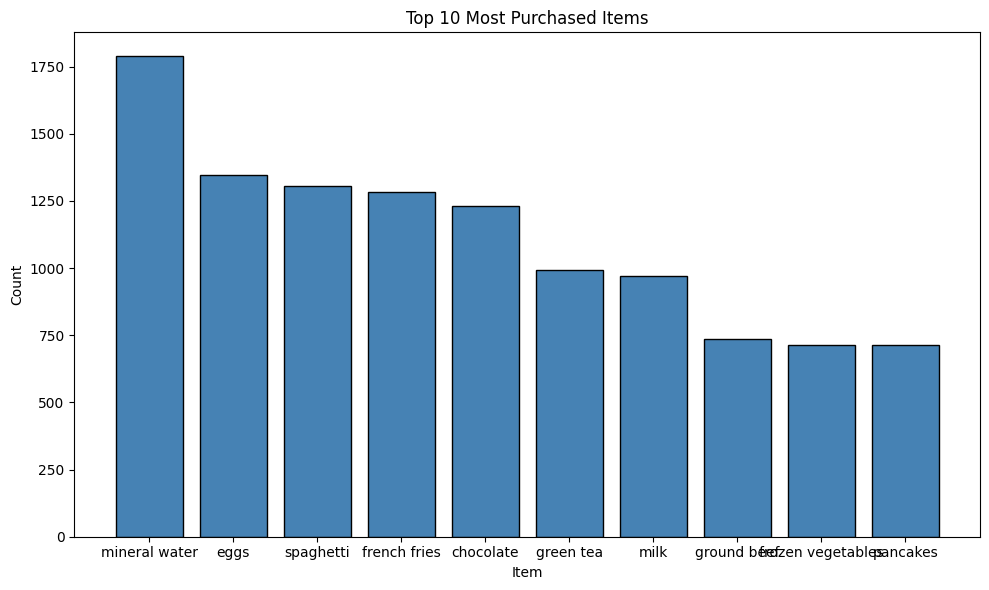

In [16]:
#Section 8: Bar Chart: Top 10 Most Purchased Items 
print("Section 8: Bar Chart -- Top 10 Most Purchase Item")
print("-" * 50)

all_items = [item for tx in transaction_list for item in tx]
item_counts = Counter(all_items)
top10 = item_counts.most_common(10)
top10_df = pd.DataFrame(top10, columns=['item', 'count'])

plt.figure(figsize=(10,6))
plt.bar(top10_df['item'], top10_df['count'], color=['steelblue'], edgecolor='black')
plt.xlabel('Item')
plt.ylabel('Count')
plt.title('Top 10 Most Purchased Items')
plt.tight_layout()
plt.savefig('Section8_top10_items.png' , bbox_inches='tight')
plt.show()

Section 9: Bar Chart -- Top 10 Pairs By Support
 * 50


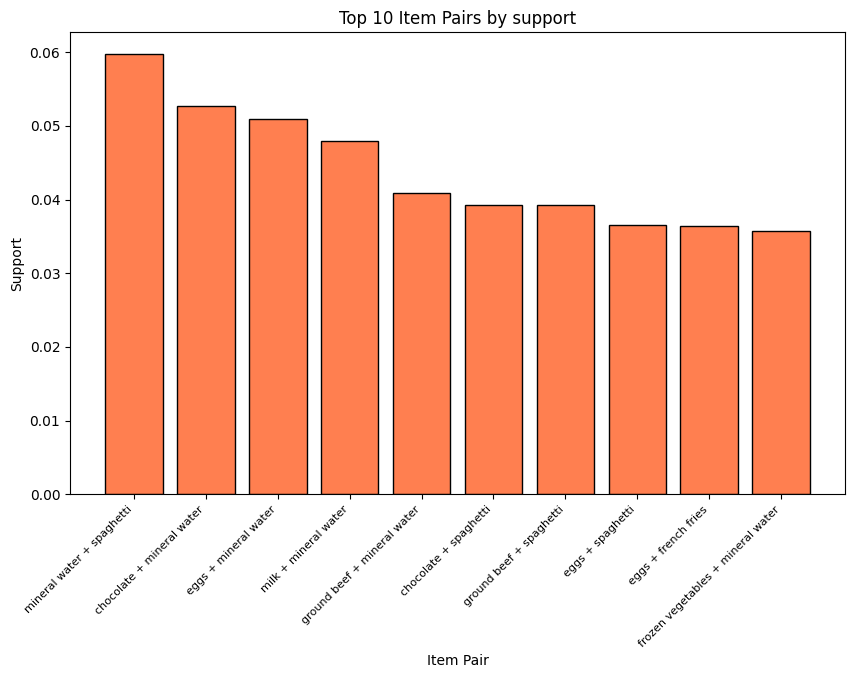

In [17]:
#Section 9 -- Bar Chart: Top 10 Item Pairs by support
print("Section 9: Bar Chart -- Top 10 Pairs By Support")
print(" * 50")

pair_counts = Counter()
for tx in transaction_list: 
    unique_items = sorted(set(tx))
    for a, b in combinations(unique_items, 2):
        pair_counts[(a,b)] += 1

n_tx = len(transaction_list)
pairs_df= pd.DataFrame([
    {'pair_str': f"{a} + {b}" , 'support': cnt / n_tx}
    for (a,b), cnt in pair_counts.items()
])
pairs_df = pairs_df.sort_values('support', ascending=False).reset_index(drop=True)
top10_pairs = pairs_df.head(10).copy()

plt.figure(figsize=(10,6))
plt.bar(top10_pairs['pair_str'], top10_pairs['support'], color='coral', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.xlabel('Item Pair')
plt.ylabel('Support')
plt.title('Top 10 Item Pairs by support')
plt.savefig('Section9_top10_pairs.png', bbox_inches='tight')
plt.show()

Section 10: Scatter Plot - Support vs Confidence
--------------------------------------------------


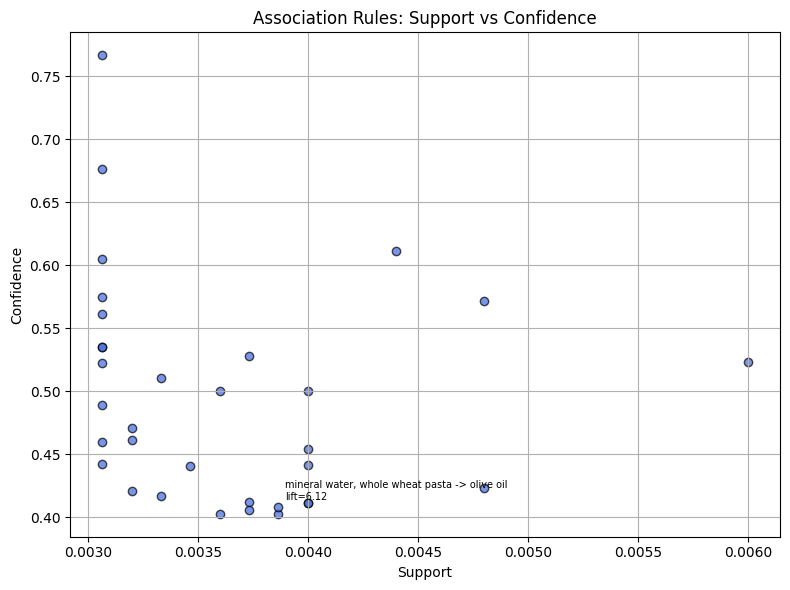

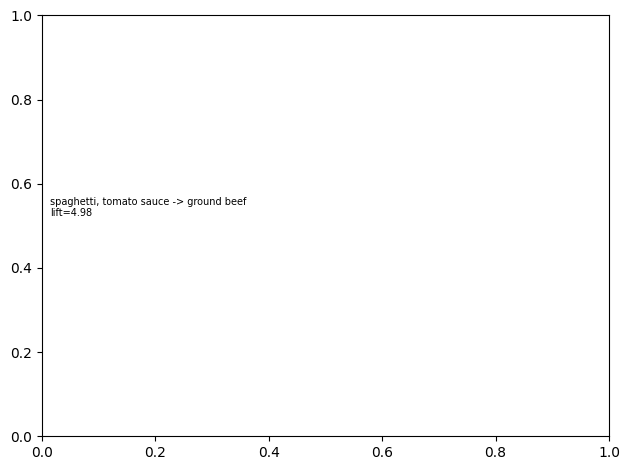

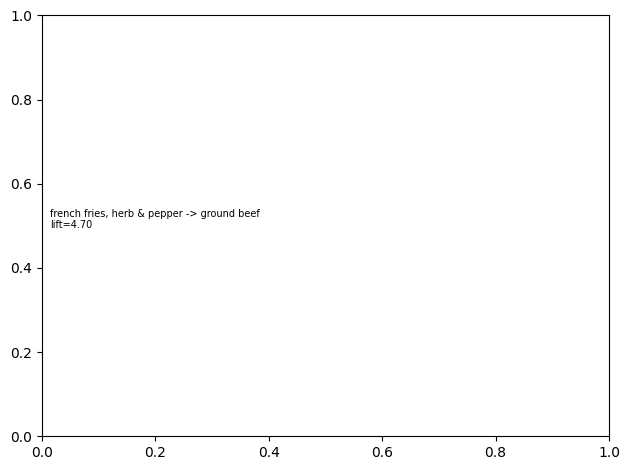

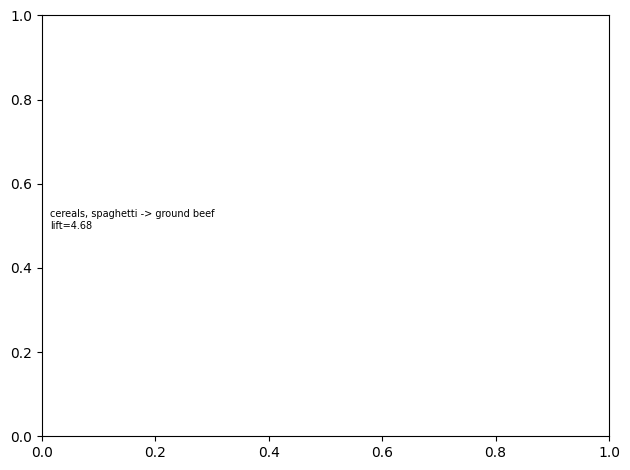

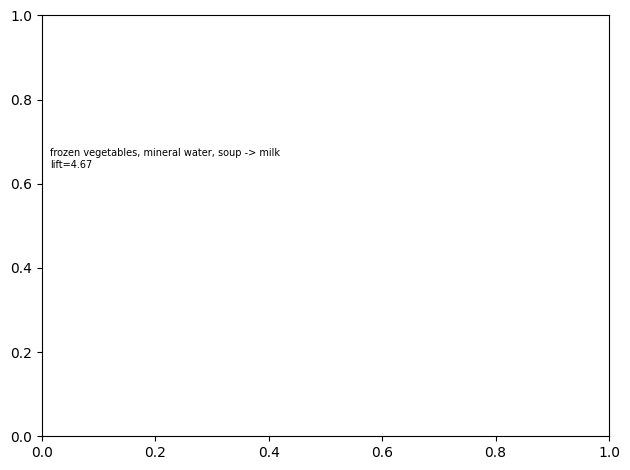

In [18]:
#Section 10: Scatter Plot: Suppport vs Confidence 
print("Section 10: Scatter Plot - Support vs Confidence")
print("-" * 50)

plt.figure(figsize=(8,6))
plt.scatter(rules_df['support'], rules_df['confidence'], alpha=0.7, edgecolors='k', color='royalblue')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence')
plt.grid(True)

#Annotate top 5 by lift
top5 = rules_df.sort_values('lift', ascending=False).head(5)
for _, row in top5.iterrows():
    label = f"{row['antecedent_item']} -> {row['consequent_item']}\nlift={row['lift']:.2f}"
    plt.annotate(label, (row['support'], row['confidence']),
                 textcoords="offset points" , xytext=(5,10), fontsize=7)
    
    plt.tight_layout()
    plt.savefig('Section10_support_vs_confidence.png', bbox_inches='tight')
    plt.show()

In [ ]:
#Section 11 -- Scatter plot: Confidence vs Lift
print("Section 11: Scatter Plot -- Confidence vs Lift")
print("-" * 50)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(rules_df['confidence'], rules_df['lift'],
           alpha=0.7, edgecolors='k', color='mediumseagreen', s=60)
ax.set_xlabel('Confidence')
ax.set_ylabel('Lift')
ax.set_title('Association Rules: Confidence vs Lift')
ax.grid(True, alpha=0.4)

# Make some space for upper part
y_min, y_max = rules_df['lift'].min(), rules_df['lift'].max()
ax.set_ylim(y_min - 0.3, y_max + 1.0)

# Stagger label offsets so the three rules near confidence ~0.46 don't overlap
label_offsets = [(40, 25), (40, -35), (-120, 35), (50, -45), (-150, -25)]

for (_, row), (dx, dy) in zip(top5.iterrows(), label_offsets):
    label = f"{row['antecedent_item']} -> {row['consequent_item']}\nlift={row['lift']:.2f}"
    ax.annotate(
        label,
        xy=(row['confidence'], row['lift']),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9),
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.7),
    )

plt.tight_layout()
plt.savefig('section11_confidence_vs_lift.png', bbox_inches='tight')
plt.show()

--------------------------------------------------


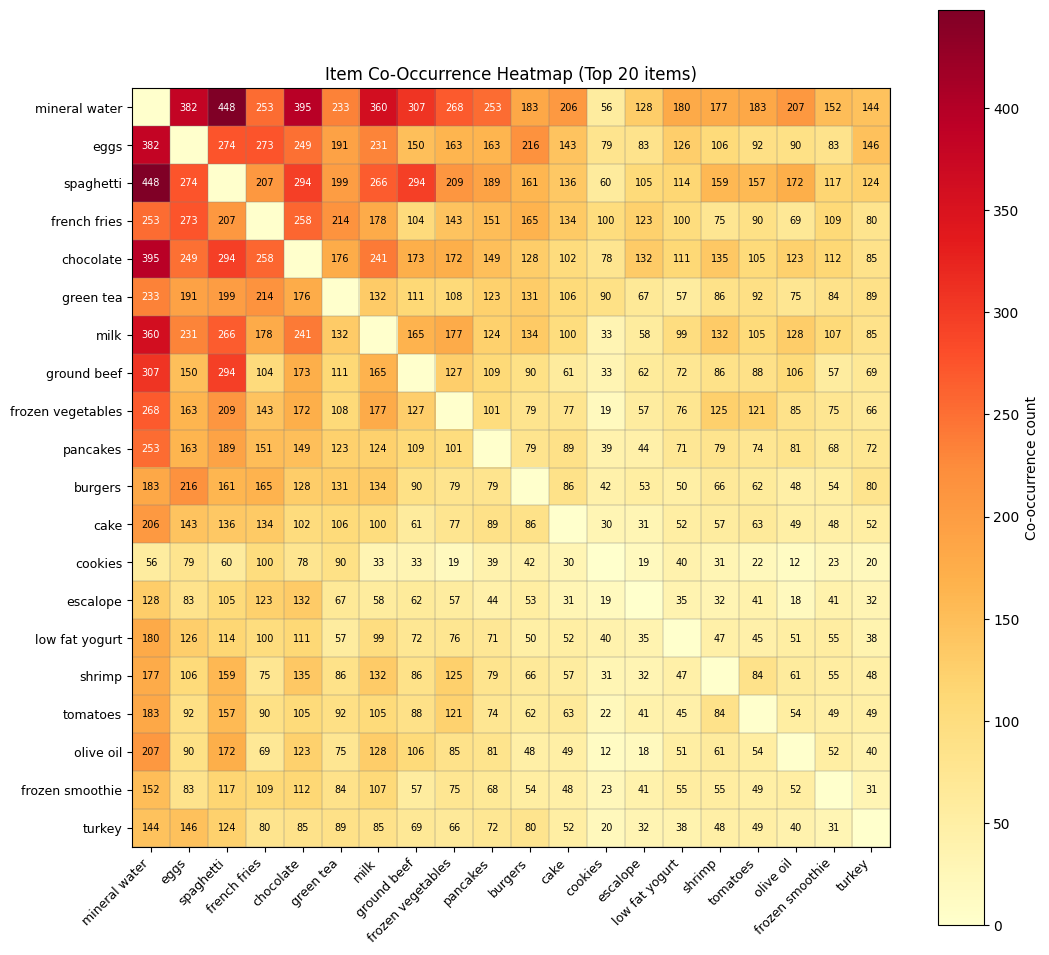

In [ ]:
print("-" * 50)

TOP_N = 20
top_items = [item for item, _ in item_counts.most_common(TOP_N)]
idx = {it: i for i, it in enumerate(top_items)}
mat = np.zeros((len(top_items), len(top_items)), dtype=int)

for tx in transaction_list:
      items_in_tx = set(tx) & set(top_items)
      for a, b in combinations(items_in_tx, 2):
          mat[idx[a], idx[b]] += 1
          mat[idx[b], idx[a]] += 1

# DO NOT fill the diagonal — leave it as 0 so the color scale fits the pair counts.
# (If you want item totals, show them in a separate bar chart, not in this heatmap.)

fig, ax = plt.subplots(figsize=(11, 10))           # square-ish, not 12x19
im = ax.imshow(mat, cmap='YlOrRd', aspect='equal') # equal => square cells
fig.colorbar(im, ax=ax, label='Co-occurrence count')

ax.set_xticks(np.arange(len(top_items)))
ax.set_yticks(np.arange(len(top_items)))
ax.set_xticklabels(top_items, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top_items, fontsize=9)

# Annotate every cell with its value
for i in range(len(top_items)):
      for j in range(len(top_items)):
          v = mat[i, j]
          if v > 0:
              ax.text(j, i, v, ha='center', va='center',
                      fontsize=7,
                      color='white' if v > mat.max()*0.5 else 'black')

# Thin grid lines between cells
ax.set_xticks(np.arange(-0.5, len(top_items), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(top_items), 1), minor=True)
ax.grid(which='minor', color='gray', linewidth=0.3)
ax.tick_params(which='minor', length=0)

ax.set_title(f'Item Co-Occurrence Heatmap (Top {TOP_N} items)')
plt.tight_layout()
plt.savefig('Section12_heatmap.png', bbox_inches='tight')
plt.show()
